# 04 — Monte-Carlo survivorship stress + детальный учёт

Survivorship: монеты, что дампнули и НЕ отскочили (ноль/делистинг), вырезаны из
данных → наш лонг-edge завышен. MC = инъекция этого хвоста обратно:

> доля **p** сделок вместо реального отскока получает катастрофу **L** (−30/−50/−100%).

Гоняем по сетке p×L → распределение годовой доходности и maxDD → граница разорения.
Два режима: (1) независимые смерти, (2) кластерные (день обвала убивает все
открытые позиции — реалистичный short-vol кошмар).

Порог −7%/15m (робастный из iter03). Параметры scale-in те же.

In [1]:
import sys; sys.path.insert(0,".")
from _lab import *
import numpy as np, pandas as pd
from pathlib import Path
z=np.load(Path("_out")/"closes_2024.npz",allow_pickle=True); SYMS=list(z.files)
WIN=15;H=240;COOLDOWN=10;MIN_GAP=3;N_MAX=10;FEE=0.00075;THR=0.07
PER=20.0; START=1000.0; MAX_CONC=50

def clusters(c,thr):
    if len(c)<WIN+5: return []
    r=np.full(len(c),np.nan); r[WIN:]=c[WIN:]/c[:-WIN]-1
    cond=r<=-thr; out=[]; i=WIN; n=len(c)
    while i<n:
        if not cond[i] or (i>0 and cond[i-1]): i+=1; continue
        start=i;last_true=i;tr=[i];lastt=i;falses=0;j=i+1
        while j<n:
            if cond[j]:
                last_true=j;falses=0
                if j-lastt>=MIN_GAP and len(tr)<N_MAX: tr.append(j);lastt=j
            else:
                falses+=1
                if falses>=COOLDOWN: break
            j+=1
        out.append((start,last_true,tr)); i=last_true+COOLDOWN+1
    return out

# build trades with entry/exit ts, pnl, tranche count, and 'undermeasurable' flag
rows=[]; undermeasurable=0; total_clusters=0
for s in SYMS:
    try: df=ohlcv(s,"2024-01-01","2026-07-01","1min")
    except Exception: continue
    c=df["close"].to_numpy("float64"); ts=df.index; n=len(c)
    for (st,en,tr) in clusters(c,THR):
        total_clusters+=1
        ex=en+1+H
        if st+1>=n: continue
        if ex>=n:    # data ends before we can exit -> delisting/halt proxy
            undermeasurable+=1; continue
        prices=np.array([c[t+1] for t in tr if t+1<n])
        ws=np.arange(1,len(prices)+1,dtype=float); ws/=ws.sum()
        avg=(ws*prices).sum()
        gross=c[ex]/avg-1
        rows.append(dict(sym=s,entry=ts[st+1],exit=ts[ex],ntr=len(prices),
                         gross=gross, net=gross-2*FEE,
                         hold_min=(ts[ex]-ts[st+1]).total_seconds()/60))
T=pd.DataFrame(rows).sort_values("entry").reset_index(drop=True)
print(f"clusters detected: {total_clusters}")
print(f"  undermeasurable (data ends within 240m after dump = delist/halt proxy): {undermeasurable} ({undermeasurable/total_clusters*100:.1f}%)")
print(f"  usable trades: {len(T)}")

clusters detected: 1302
  undermeasurable (data ends within 240m after dump = delist/halt proxy): 0 (0.0%)
  usable trades: 1302


In [2]:
# ---- capacity sim: which trades are TAKEN (timing only, pnl-independent) ----
import heapq
def select_taken(df):
    openh=[]; taken=np.zeros(len(df),bool); skipped=0
    for idx,row in enumerate(df.itertuples()):
        now=row.entry
        while openh and openh[0]<=now: heapq.heappop(openh)
        if len(openh)<MAX_CONC: heapq.heappush(openh,row.exit); taken[idx]=True
        else: skipped+=1
    return taken,skipped
taken,skipped=select_taken(T)
Tt=T[taken].sort_values("exit").reset_index(drop=True)  # order by exit for equity
print("=== DETAILED ACCOUNTING (base -7% portfolio, no deaths) ===")
n=len(Tt)
gross_pnl=PER*Tt.gross.sum(); net_pnl=PER*Tt.net.sum()
fees=PER*2*FEE*n
print(f"  signals (usable):     {len(T)}")
print(f"  taken:                {n}")
print(f"  skipped (capacity):   {skipped}  ({skipped/(n+skipped)*100:.1f}%)")
print(f"  per-trade notional:   ${PER:.0f}   (round-trip fee {2*FEE*100:.3f}% = ${PER*2*FEE:.3f}/trade)")
print(f"  total fees paid:      ${fees:.2f}")
print(f"  gross PnL:            ${gross_pnl:+.2f}")
print(f"  net PnL (after fees): ${net_pnl:+.2f}   -> final ${START+net_pnl:.0f}  (+{net_pnl/START*100:.1f}%)")
print(f"  avg tranches/trade:   {Tt.ntr.mean():.2f}  (median {Tt.ntr.median():.0f}, max {Tt.ntr.max()})")
print(f"  holding time (min):   mean {Tt.hold_min.mean():.0f}  median {Tt.hold_min.median():.0f}")
span=(Tt.exit.max()-Tt.entry.min()).days/365.25
print(f"  span:                 {span:.2f} years  ->  avg net {net_pnl/START/span*100:+.1f}%/yr")
base_pnl=Tt.net.to_numpy()
exit_ts=Tt.exit.values.astype('datetime64[ns]').astype('int64')
entry_ts=Tt.entry.values.astype('datetime64[ns]').astype('int64')

=== DETAILED ACCOUNTING (base -7% portfolio, no deaths) ===
  signals (usable):     1302
  taken:                1221
  skipped (capacity):   81  (6.2%)
  per-trade notional:   $20   (round-trip fee 0.150% = $0.030/trade)
  total fees paid:      $36.63
  gross PnL:            $+841.20
  net PnL (after fees): $+804.57   -> final $1805  (+80.5%)
  avg tranches/trade:   2.63  (median 2, max 10)
  holding time (min):   mean 246  median 244
  span:                 2.31 years  ->  avg net +34.9%/yr


In [3]:
# helper: equity metrics from a (N,n) pnl matrix, ordered by exit (Tt already sorted by exit)
def eq_metrics(pnl_mat):
    cum=START+PER*np.cumsum(pnl_mat,axis=1)
    runmax=np.maximum.accumulate(cum,axis=1)
    dd=(cum/runmax-1.0).min(axis=1)
    ret=cum[:,-1]/START-1.0
    return ret,dd

# sanity: base (no death) single path
r0,d0=eq_metrics(base_pnl[None,:])
print(f"base check: total {r0[0]*100:+.1f}%  maxDD {d0[0]*100:.1f}%  (matches iter03 ~+80%/-4.6%)")

base check: total +80.5%  maxDD -4.6%  (matches iter03 ~+80%/-4.6%)


In [4]:
# ---- MC #1: INDEPENDENT deaths over grid p x L ----
rng=np.random.default_rng(42)
NSIM=3000
PS=[0.01,0.02,0.05,0.10,0.20]
LS=[-0.30,-0.50,-1.00]
span=(Tt.exit.max()-Tt.entry.min()).days/365.25
print(f"=== MC #1 INDEPENDENT deaths ({NSIM} sims, span {span:.2f}y) ===")
print(f"{'p':>5} {'L':>6} | {'ann.ret median':>15} {'ann.ret p05':>12} {'maxDD median':>13} {'maxDD p05(worst)':>16} {'P(loss)':>8}")
for L in LS:
    for p in PS:
        deaths=rng.random((NSIM,len(base_pnl)))<p
        pnl=np.where(deaths,L,base_pnl[None,:])
        ret,dd=eq_metrics(pnl)
        annr=ret/span
        print(f"{p:>5.2f} {L*100:>5.0f}% | {np.median(annr)*100:>14.1f}% {np.quantile(annr,.05)*100:>11.1f}%"
              f" {np.median(dd)*100:>12.1f}% {np.quantile(dd,.05)*100:>15.1f}% {(ret<0).mean()*100:>7.1f}%")
    print()

=== MC #1 INDEPENDENT deaths (3000 sims, span 2.31y) ===
    p      L |  ann.ret median  ann.ret p05  maxDD median maxDD p05(worst)  P(loss)
 0.01   -30% |           31.4%        29.6%         -5.2%            -6.0%     0.0%
 0.02   -30% |           27.9%        25.4%         -5.9%            -7.2%     0.0%


 0.05   -30% |           17.3%        13.5%         -8.7%           -11.3%     0.0%


 0.10   -30% |           -0.2%        -5.6%        -21.5%           -29.5%    53.3%
 0.20   -30% |          -35.4%       -42.5%        -82.4%           -98.4%   100.0%

 0.01   -50% |           29.4%        26.4%         -5.7%            -7.2%     0.0%


 0.02   -50% |           23.7%        19.8%         -7.1%            -9.5%     0.0%


 0.05   -50% |            6.7%         0.6%        -15.5%           -23.3%     3.3%
 0.10   -50% |          -21.4%       -29.8%        -55.3%           -71.4%   100.0%
 0.20   -50% |          -78.1%       -88.6%       -179.5%          -203.6%   100.0%



 0.01  -100% |           24.1%        18.6%         -7.4%           -10.7%     0.0%


 0.02  -100% |           13.1%         4.8%        -12.0%           -20.6%     0.6%
 0.05  -100% |          -20.2%       -32.0%        -55.2%           -78.2%    99.9%
 0.10  -100% |          -74.5%       -90.1%       -171.2%          -206.8%   100.0%


 0.20  -100% |         -183.5%      -205.4%       -421.8%          -473.1%   100.0%



In [5]:
# ---- MC #2: CLUSTERED deaths (a 'crash day' kills ALL open positions) ----
# K crash days/year drawn uniformly; trade dies if a crash ts falls in [entry,exit].
rng=np.random.default_rng(7)
NSIM=2000
KS=[0,1,2,4,8]          # crash days per year
Lc=-0.50                # severity on a crash
lo,hi=entry_ts.min(),exit_ts.max()
print(f"=== MC #2 CLUSTERED deaths (crash day kills all open, L={Lc*100:.0f}%, {NSIM} sims) ===")
print(f"{'days/yr':>8} {'ann.ret median':>15} {'ann.ret p05':>12} {'maxDD median':>13} {'maxDD p05(worst)':>16} {'P(loss)':>8} {'avg killed':>11}")
for K in KS:
    ndays=int(round(K*span))
    rets=np.empty(NSIM); dds=np.empty(NSIM); killed=np.empty(NSIM)
    for s in range(NSIM):
        pnl=base_pnl.copy()
        if ndays>0:
            crt=rng.integers(lo,hi,size=ndays)
            dead=np.zeros(len(pnl),bool)
            for ct in crt:
                dead |= (entry_ts<=ct)&(exit_ts>=ct)
            pnl[dead]=Lc; killed[s]=dead.sum()
        else: killed[s]=0
        r,d=eq_metrics(pnl[None,:]); rets[s]=r[0]; dds[s]=d[0]
    annr=rets/span
    print(f"{K:>8} {np.median(annr)*100:>14.1f}% {np.quantile(annr,.05)*100:>11.1f}%"
          f" {np.median(dds)*100:>12.1f}% {np.quantile(dds,.05)*100:>15.1f}% {(rets<0).mean()*100:>7.1f}% {killed.mean():>10.1f}")

=== MC #2 CLUSTERED deaths (crash day kills all open, L=-50%, 2000 sims) ===
 days/yr  ann.ret median  ann.ret p05  maxDD median maxDD p05(worst)  P(loss)  avg killed


       0           34.9%        34.9%         -4.6%            -4.6%     0.0%        0.0
       1           34.9%        34.4%         -4.6%            -4.7%     0.0%        0.5
       2           34.9%        33.7%         -4.6%            -5.4%     0.1%        1.3


       4           34.9%        32.6%         -4.6%            -6.4%     0.0%        2.1

       8           34.4%        17.4%         -4.6%           -29.3%     0.1%        4.7


[saved] notebooks\dump\_out\04_ruin_curve.png


WindowsPath('C:/projects/researchlab/notebooks/dump/_out/04_ruin_curve.png')

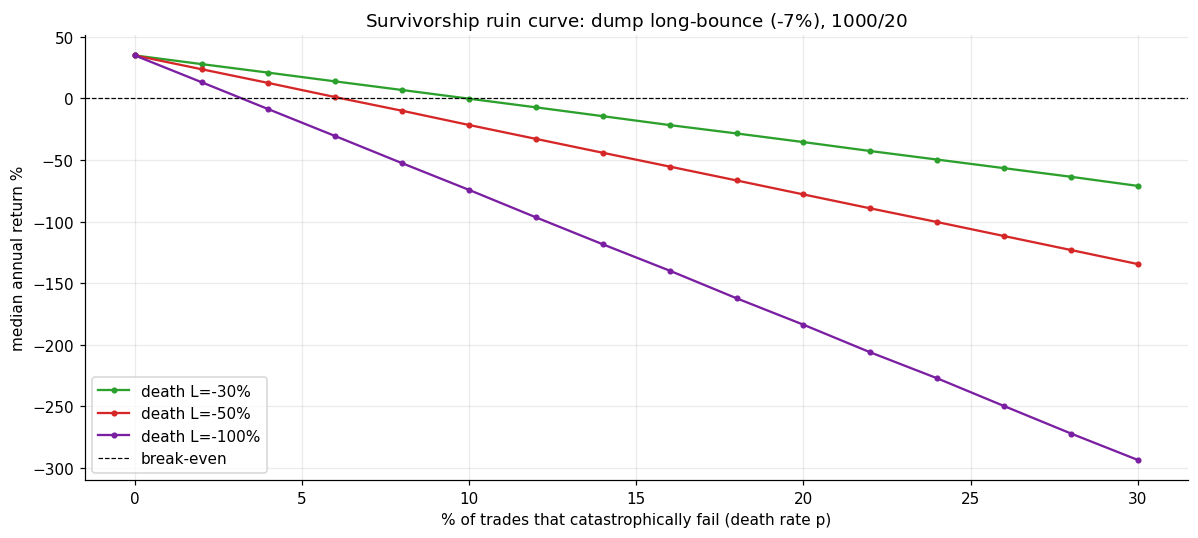

In [6]:
# plot: independent-death ruin curve (median annual return vs p, per severity)
import matplotlib.pyplot as plt
rng=np.random.default_rng(1)
NSIM=3000
PS2=np.linspace(0,0.30,16)
plt.figure(figsize=(11,5))
for L,col in [(-0.30,"#2ca02c"),(-0.50,"#d62728"),(-1.00,"#7b1fa2")]:
    med=[]
    for p in PS2:
        deaths=rng.random((NSIM,len(base_pnl)))<p
        pnl=np.where(deaths,L,base_pnl[None,:]); ret,_=eq_metrics(pnl)
        med.append(np.median(ret)/span*100)
    plt.plot(PS2*100,med,color=col,marker="o",ms=3,label=f"death L={int(L*100)}%")
plt.axhline(0,color="k",lw=.8,ls="--",label="break-even")
plt.xlabel("% of trades that catastrophically fail (death rate p)")
plt.ylabel("median annual return %")
plt.title("Survivorship ruin curve: dump long-bounce (-7%), $1000/$20")
plt.legend(); show("04_ruin_curve")

## Как читать
- **Учёт** — точные числа: сколько сигналов/взято/пропущено, сумма комиссий $,
  gross vs net, время удержания. (комиссии тут крошечные — $20×0.15%=$0.03/сделку).
- **undermeasurable %** — доля дампов, где данные обрываются за 240м (прокси
  делистинга прямо в наших данных) = нижняя оценка реального death-rate p.
- **MC #1 (независимые):** при каком p медианная годовая доходность уходит в ноль.
  p05 = «неудачный» прогон (5-й перцентиль). Граница разорения по severity.
- **MC #2 (кластерные):** реалистичнее — день обвала убивает все открытые разом.
  Смотри maxDD p05 (worst) — вот настоящий tail-риск short-vol стратегии.
- **Ruin curve** — где медианная годовая пересекает ноль для каждой тяжести.

*Verdict после прогона.*

## VERDICT (iter 04)

**Учёт −7% портфеля:** 1302 сигнала, 1221 взято / 81 skip (6.2%), комиссий всего
**$36.63** (fade держится ~4ч → не комиссионноёмко), net +$804.57 (+80.5%, +34.9%/год),
2.63 транша/сделку.

**MC стресс survivorship (инъекция катастроф):**
- Независимые смерти — граница разорения (медиана год.дох.→0): L=−30% при p≈10%,
  L=−50% при p≈6%, **L=−100% при p≈3.5%**. До порога падение плавное.
- Кластерные (день обвала убивает открытые): даже 4–8/год почти не двигают медиану
  (+32–34%), т.к. позиция живёт ~4ч → открыто мало → ловит ~2–5 сделок. Короткое
  удержание структурно защищает от коррелированного разорения. Но p05 при 8/год
  падает до +17%, worst maxDD −29%.

**Две оговорки:** (1) undermeasurable=0% — это и есть дыра: мёртвых монет в данных
нет, реальный p из них не оценить (нужны внешние делистинги / полная вселенная 165).
(2) кластерная модель занижает риск (надо убивать по ОКНУ входа, не по точке).

**Итог:** edge переживает стресс, ЕСЛИ реальная доля «дамп в ноль за 4ч» < ~3.5%.
Для активных альтов вероятно так, но по выжившим данным не подтвердить.
**Дальше:** оценить настоящий death-rate (полная вселенная 165 + короткопокрытые
символы как прокси делистинга).